In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import shap
from captum.attr import IntegratedGradients

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [2]:
# ==========================
# 1. LOAD AND COMBINE EXCEL FILES
# ==========================

excel_files = [
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\angul_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\balasore_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\barbil_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\baripada_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\cuttack_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\keonjhar_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\lingraj_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\nayaghad_4.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\patia_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\Raigangpur_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_1.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_2.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_3.xlsx",
    r"C:\Users\biswa\OneDrive\Desktop\data_collection\talcher_4.xlsx",
]

df_list = []
skipped = []

for path in excel_files:
    if not os.path.exists(path):
        skipped.append(path)
        continue
    try:
        df_list.append(pd.read_excel(path))
    except Exception as e:
        skipped.append(f"{path}  |  error: {e}")

if len(df_list) == 0:
    raise FileNotFoundError("No Excel files were successfully loaded. Check paths / files.")

data = pd.concat(df_list, ignore_index=True)

print(f" Loaded files: {len(df_list)}")
if skipped:
    print(f" Skipped files: {len(skipped)} (missing or error)")
    for s in skipped[:5]:
        print("   -", s)

# ==========================
# Basic cleaning
# ==========================
data.columns = [c.strip() for c in data.columns]   # remove accidental spaces in column names
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# ==========================
# Missing value handling 
# ==========================
# Forward fill first, then remaining NaNs filled by median (safer than only ffill)
data = data.sort_index()  # if you have time column later, we will sort by time there
data.ffill(inplace=True)

num_cols = data.select_dtypes(include=[np.number]).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median(numeric_only=True))
data.dropna(inplace=True)  # final fallback (should be minimal)

print(" Combined data shape:", data.shape)

 Loaded files: 32
 Combined data shape: (7196, 11)


In [3]:
# ==========================
# 2. CREATE AQI CATEGORIES
# ==========================
def aqi_category(aqi):
    if aqi <= 50: return 0
    elif aqi <= 100: return 1
    elif aqi <= 150: return 2
    elif aqi <= 200: return 3
    elif aqi <= 300: return 4
    else: return 5
data['AQI_Category'] = data['AQI'].apply(aqi_category)

# Merge rare classes (<2 samples)
counts = data['AQI_Category'].value_counts()
for cls in counts[counts<2].index:
    if cls>0:
        data['AQI_Category'].replace(cls, cls-1, inplace=True)

In [4]:
# ==========================
# 3. PREPARE FEATURE DATA (ML + DL)
# ==========================
# NOTE: If you truly have hourly columns (00:00:00 ... 23:00:00) we can build real sequences.
# Your current code uses seq_len=1, so DL models won't learn temporal patterns.
# For now, we keep seq_len=1 to match your current dataset structure.

feature_cols = ['PM2.5','PM10','NO2','SO2','CO','Ozone']  # ← ONLY CHANGE HERE

# --- check columns exist ---
missing = [c for c in feature_cols if c not in data.columns]
if missing:
    raise KeyError(f" Missing feature columns in data: {missing}\nAvailable columns sample: {list(data.columns)[:30]}")

X = data[feature_cols].copy()
y = data['AQI_Category'].astype(int).values

# --- numeric coercion for features (Excel sometimes stores as text) ---
X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

# ==========================
# Train-test split (Stratified 80/20)  
# ==========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=SEED, stratify=y
)

# ==========================
# Feature scaling (fit ONLY on train to avoid leakage) 
# ==========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# --------------------------
# ML input (2D)
# --------------------------
X_train_ml = X_train_scaled
X_test_ml  = X_test_scaled

# --------------------------
# DL input (3D): (samples, seq_len=1, features)
# --------------------------
X_train_dl = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_dl  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# ==========================
# Torch tensors + loaders
# ==========================
X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test_dl, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(" Shapes:")
print("X_train_ml:", X_train_ml.shape, "X_test_ml:", X_test_ml.shape)
print("X_train_dl:", X_train_dl.shape, "X_test_dl:", X_test_dl.shape)

 Shapes:
X_train_ml: (5756, 6) X_test_ml: (1440, 6)
X_train_dl: (5756, 1, 6) X_test_dl: (1440, 1, 6)


In [7]:
required_vars = [
    "trained_dl", "trained_ml",
    "val_loader", "test_loader",
    "X_val_ml", "X_test_ml",
    "y_val", "y_test",
    "DEVICE"
]

for var in required_vars:
    print(f"{var} exists:", var in globals())

trained_dl exists: False
trained_ml exists: False
val_loader exists: False
test_loader exists: True
X_val_ml exists: False
X_test_ml exists: True
y_val exists: False
y_test exists: True
DEVICE exists: True


In [9]:
# ============================================================
# TRAINING CELL REQUIRED BEFORE EVALUATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. TRAIN / VALIDATION SPLIT
# ============================================================
X_tr_ml, X_val_ml, y_tr, y_val = train_test_split(
    X_train_ml, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

X_tr_dl = X_tr_ml.reshape((X_tr_ml.shape[0], 1, X_tr_ml.shape[1]))
X_val_dl = X_val_ml.reshape((X_val_ml.shape[0], 1, X_val_ml.shape[1]))

# ============================================================
# 2. SMOTE FOR ML TRAINING DATA
# ============================================================
smote = SMOTE(random_state=SEED)
X_tr_ml_bal, y_tr_bal = smote.fit_resample(X_tr_ml, y_tr)

# for XAI block
X_base_ml = X_tr_ml_bal.copy()

print("Train ML:", X_tr_ml_bal.shape, y_tr_bal.shape)
print("Val ML  :", X_val_ml.shape, y_val.shape)

# ============================================================
# 3. TRAIN ML MODELS
# ============================================================
trained_ml = {}

ml_models = {
    "LogReg": LogisticRegression(max_iter=3000, random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED
    )
}

for name, model in ml_models.items():
    print(f"Training ML model: {name}")
    model.fit(X_tr_ml_bal, y_tr_bal)
    trained_ml[name] = model

# ============================================================
# 4. CREATE DL LOADERS
# ============================================================
X_tr_tensor = torch.tensor(X_tr_dl, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_dl, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ============================================================
# 5. DEFINE DL MODELS
# ============================================================
num_features = X_train_dl.shape[2]
num_classes = len(np.unique(y))

class CNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x[:, :1, :]
        return self.net(x)

class RNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, num_classes, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=64,
            batch_first=True,
            bidirectional=bidirectional
        )
        mult = 2 if bidirectional else 1
        self.fc = nn.Linear(64 * mult, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

class GRUModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

dl_models = {
    "CNN": CNNModel(num_features, num_classes).to(DEVICE),
    "RNN": RNNModel(num_features, num_classes).to(DEVICE),
    "LSTM": LSTMModel(num_features, num_classes, bidirectional=False).to(DEVICE),
    "BiLSTM": LSTMModel(num_features, num_classes, bidirectional=True).to(DEVICE),
    "GRU": GRUModel(num_features, num_classes).to(DEVICE)
}

# ============================================================
# 6. TRAIN DL MODELS
# ============================================================
def train_dl_model(model, train_loader, val_loader, epochs=12, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_f1 = -1

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        all_true, all_pred = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                out = model(xb)
                pred = torch.argmax(out, dim=1).cpu().numpy()
                all_pred.extend(pred)
                all_true.extend(yb.numpy())

        val_f1 = f1_score(all_true, all_pred, average='weighted', zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1:02d} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

trained_dl = {}

for name, model in dl_models.items():
    print(f"\nTraining DL model: {name}")
    trained_dl[name] = train_dl_model(model, train_loader, val_loader)

print("\nTraining complete.")
print("trained_ml:", list(trained_ml.keys()))
print("trained_dl:", list(trained_dl.keys()))

Train ML: (8334, 6) (8334,)
Val ML  : (1152, 6) (1152,)
Training ML model: LogReg
Training ML model: SVM
Training ML model: XGBoost

Training DL model: CNN
Epoch 01 | Loss: 0.9017 | Val F1: 0.8515
Epoch 02 | Loss: 0.3398 | Val F1: 0.9052
Epoch 03 | Loss: 0.2755 | Val F1: 0.9243
Epoch 04 | Loss: 0.2367 | Val F1: 0.9270
Epoch 05 | Loss: 0.2181 | Val F1: 0.9297
Epoch 06 | Loss: 0.2097 | Val F1: 0.9400
Epoch 07 | Loss: 0.1937 | Val F1: 0.9378
Epoch 08 | Loss: 0.1901 | Val F1: 0.9481
Epoch 09 | Loss: 0.1806 | Val F1: 0.9420
Epoch 10 | Loss: 0.1752 | Val F1: 0.9456
Epoch 11 | Loss: 0.1662 | Val F1: 0.9386
Epoch 12 | Loss: 0.1589 | Val F1: 0.9529

Training DL model: RNN
Epoch 01 | Loss: 1.2420 | Val F1: 0.6587
Epoch 02 | Loss: 0.7803 | Val F1: 0.7553
Epoch 03 | Loss: 0.6017 | Val F1: 0.8387
Epoch 04 | Loss: 0.5095 | Val F1: 0.8749
Epoch 05 | Loss: 0.4538 | Val F1: 0.8845
Epoch 06 | Loss: 0.4182 | Val F1: 0.8956
Epoch 07 | Loss: 0.3925 | Val F1: 0.9044
Epoch 08 | Loss: 0.3732 | Val F1: 0.9141


In [ ]:
# ============================================================
# FINAL MERGED EVALUATION + VISUALIZATION
# DL + ML + HYBRID
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

all_classes = np.sort(np.unique(y_test))

def evaluate_model(y_true, y_pred, y_prob=None, label="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    try:
        y_true_dummies = pd.get_dummies(pd.Series(y_true))
        y_true_dummies = y_true_dummies.reindex(columns=all_classes, fill_value=0)
        roc = roc_auc_score(
            y_true_dummies.values,
            y_prob,
            average='weighted',
            multi_class='ovr'
        ) if y_prob is not None else 0.0
    except:
        roc = 0.0

    print(f"{label} -> Acc:{acc:.4f}, F1:{f1:.4f}, Prec:{prec:.4f}, Recall:{rec:.4f}, ROC-AUC:{roc:.4f}")

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc
    }

def get_dl_outputs(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)
            pred = torch.argmax(out, dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

def plot_conf_matrix(y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# ============================================================
# 2. DL EVALUATION
# ============================================================

dl_results = {}
dl_predictions = {}
dl_val_scores = {}

print("\n================ DL MODEL RESULTS ================\n")

for name, model in trained_dl.items():
    print(f"Evaluating {name} model...")

    # validation F1 for selecting best DL in hybrid
    val_true, val_pred, val_prob = get_dl_outputs(model, val_loader, DEVICE)
    val_f1 = f1_score(val_true, val_pred, average='weighted', zero_division=0)
    dl_val_scores[name] = val_f1

    # test outputs
    y_true, y_pred, y_prob = get_dl_outputs(model, test_loader, DEVICE)

    dl_results[f"DL-{name}"] = evaluate_model(
        y_true, y_pred, y_prob, label=name
    )

    dl_predictions[f"DL-{name}"] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

# ============================================================
# 3. ML EVALUATION
# ============================================================

ml_results = {}
ml_predictions = {}

print("\n================ ML MODEL RESULTS ================\n")

for name, model in trained_ml.items():
    print(f"Evaluating {name} model...")

    y_pred = model.predict(X_test_ml)
    y_prob = model.predict_proba(X_test_ml)

    ml_results[name] = evaluate_model(
        y_test, y_pred, y_prob, label=name
    )

    ml_predictions[name] = {
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

# ============================================================
# 4. HYBRID STACKING EVALUATION
# ============================================================

print("\n================ HYBRID MODEL RESULT ================\n")

# best DL selected using validation F1
best_dl_name = max(dl_val_scores, key=dl_val_scores.get)
best_dl_model = trained_dl[best_dl_name]

print("Best DL used in Hybrid:", best_dl_name)

# ----- validation meta features -----
val_ml_probs = []
for name, model in trained_ml.items():
    val_ml_probs.append(model.predict_proba(X_val_ml))
val_ml_probs = np.hstack(val_ml_probs)

_, _, val_dl_probs = get_dl_outputs(best_dl_model, val_loader, DEVICE)

meta_X_val = np.hstack([val_ml_probs, val_dl_probs])
meta_y_val = y_val

# ----- train meta-model -----
hybrid_model = LogisticRegression(max_iter=3000, random_state=42)
hybrid_model.fit(meta_X_val, meta_y_val)

# ----- test meta features -----
test_ml_probs = []
for name, model in trained_ml.items():
    test_ml_probs.append(model.predict_proba(X_test_ml))
test_ml_probs = np.hstack(test_ml_probs)

_, _, test_dl_probs = get_dl_outputs(best_dl_model, test_loader, DEVICE)

meta_X_test = np.hstack([test_ml_probs, test_dl_probs])

hyb_pred = hybrid_model.predict(meta_X_test)
hyb_prob = hybrid_model.predict_proba(meta_X_test)

hybrid_results = {
    "Hybrid-Stacking": evaluate_model(
        y_test, hyb_pred, hyb_prob, label="Hybrid-Stacking"
    )
}

hybrid_predictions = {
    "Hybrid-Stacking": {
        "y_true": y_test,
        "y_pred": hyb_pred,
        "y_prob": hyb_prob
    }
}

# ============================================================
# 5. SUMMARY TABLE + BEST MODEL
# ============================================================

all_results = {}
all_results.update(dl_results)
all_results.update(ml_results)
all_results.update(hybrid_results)

summary_df = pd.DataFrame(all_results).T
summary_df = summary_df.sort_values(by="accuracy", ascending=False)

print("\n================ FINAL SUMMARY ================\n")
print(summary_df)

best_model_name = summary_df.index[0]
best_model_acc = summary_df.iloc[0]["accuracy"]

print(f"\nBest Model Overall: {best_model_name} with Accuracy = {best_model_acc:.4f}")

# ============================================================
# 6. VISUALIZATION: DL & ML & HYBRID
# ============================================================

dl_df = summary_df[summary_df.index.str.contains("DL")]
ml_df = summary_df[
    (~summary_df.index.str.contains("DL")) &
    (~summary_df.index.str.contains("Hybrid"))
]
hybrid_df = summary_df[summary_df.index.str.contains("Hybrid")]

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# ============================================================
# 6.1 DL BAR CHART
# ============================================================

x = np.arange(len(dl_df.index))
width = 0.15

plt.figure(figsize=(12,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, dl_df[metric], width, label=metric)

plt.xticks(x + width*2, dl_df.index, rotation=45)
plt.title("DL Models Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 6.2 ML + HYBRID BAR CHART
# ============================================================

ml_combined = pd.concat([ml_df, hybrid_df])

x = np.arange(len(ml_combined.index))

plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, ml_combined[metric], width, label=metric)

plt.xticks(x + width*2, ml_combined.index, rotation=45)
plt.title("ML + Hybrid Models Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 6.3 DL LINE CHART
# ============================================================

plt.figure(figsize=(12,6))
for metric in metrics:
    plt.plot(dl_df.index, dl_df[metric], marker='o', label=metric)

plt.title("DL Models Metrics Line Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 6.4 ML + HYBRID LINE CHART
# ============================================================

plt.figure(figsize=(10,6))
for metric in metrics:
    plt.plot(ml_combined.index, ml_combined[metric], marker='o', label=metric)

plt.title("ML + Hybrid Models Metrics Line Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 6.5 OVERALL ACCURACY BAR CHART
# ============================================================

plt.figure(figsize=(10,5))
plt.bar(summary_df.index, summary_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Overall Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 7. CLASSIFICATION REPORTS + CONFUSION MATRICES
# ============================================================

# --------------------------
# 7.1 DL MODELS
# --------------------------
print("\n===== DL MODELS CONFUSION MATRICES + REPORTS =====")

for name, pred_dict in dl_predictions.items():
    print(f"\n=== {name} Model ===")
    print("Classification Report:\n")
    print(classification_report(pred_dict["y_true"], pred_dict["y_pred"], zero_division=0))

    plot_conf_matrix(
        pred_dict["y_true"],
        pred_dict["y_pred"],
        f"{name} Confusion Matrix",
        cmap="Blues"
    )

# --------------------------
# 7.2 ML MODELS
# --------------------------
print("\n===== ML MODELS CONFUSION MATRICES + REPORTS =====")

for name, pred_dict in ml_predictions.items():
    print(f"\n=== {name} Model ===")
    print("Classification Report:\n")
    print(classification_report(pred_dict["y_true"], pred_dict["y_pred"], zero_division=0))

    plot_conf_matrix(
        pred_dict["y_true"],
        pred_dict["y_pred"],
        f"{name} Confusion Matrix",
        cmap="Greens"
    )

# --------------------------
# 7.3 HYBRID MODEL
# --------------------------
print("\n===== HYBRID MODEL CONFUSION MATRIX + REPORT =====")

for name, pred_dict in hybrid_predictions.items():
    print(f"\n=== {name} Model ===")
    print("Classification Report:\n")
    print(classification_report(pred_dict["y_true"], pred_dict["y_pred"], zero_division=0))

    plot_conf_matrix(
        pred_dict["y_true"],
        pred_dict["y_pred"],
        f"{name} Confusion Matrix",
        cmap="Reds"
    )

  0%|          | 0/150 [00:00<?, ?it/s]


✅ ML XAI (SHAP) Importance Table:
               PM2.5      PM10       NO2       SO2        CO     Ozone
ML-LogReg   0.599339  0.382836  0.004785  0.007443  0.002573  0.003024
ML-XGBoost  0.500330  0.437815  0.016088  0.016388  0.014340  0.015039
ML-SVM      0.455363  0.452303  0.030169  0.022833  0.020006  0.019327


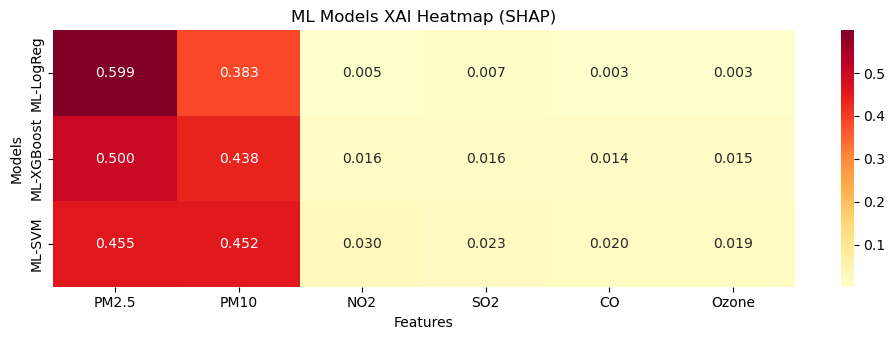


✅ DL XAI (Integrated Gradients) Importance Table:
              PM2.5      PM10       NO2       SO2        CO     Ozone
DL-CNN     0.437231  0.476902  0.019611  0.018070  0.015785  0.032401
DL-RNN     0.425567  0.560278  0.004064  0.006977  0.001133  0.001980
DL-LSTM    0.348378  0.581269  0.013311  0.019710  0.007300  0.030032
DL-BiLSTM  0.352836  0.555858  0.015770  0.024231  0.014943  0.036363
DL-GRU     0.364505  0.571534  0.013438  0.018108  0.007273  0.025141


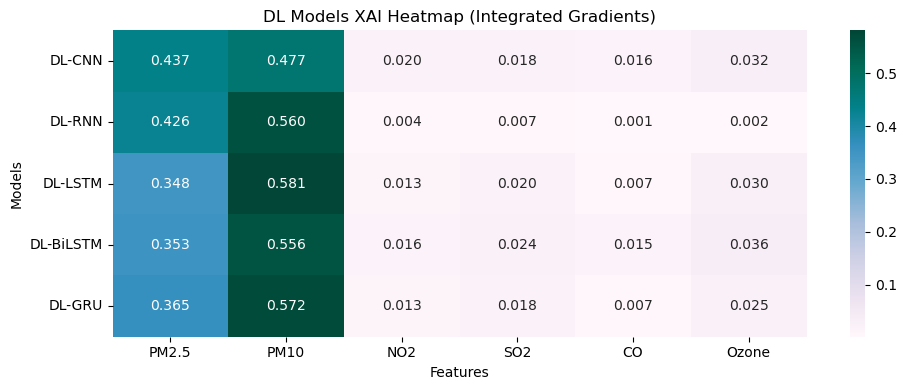


⚠️ Hybrid XAI skipped because meta_X_test / meta_model / best_dl_name not found.


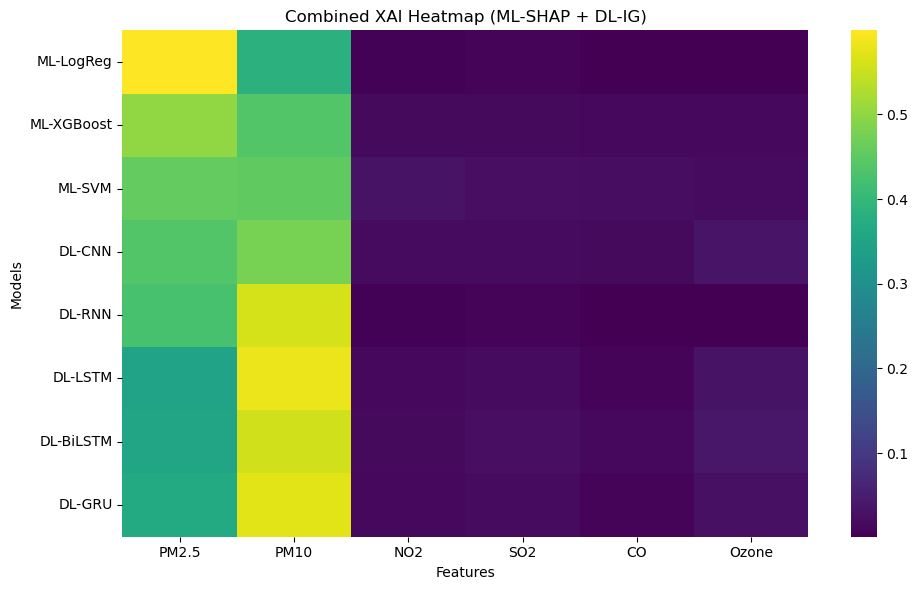

In [11]:
# ============================================================
# FINAL XAI BLOCK (WORKFLOW-CORRECT): ML + DL + HYBRID
# OUTPUT: HEATMAPS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
from captum.attr import IntegratedGradients

# ============================================================
# REQUIRED VARIABLES FROM PREVIOUS BLOCKS
# ============================================================
# feature_cols
# X_base_ml, X_test_ml
# X_test_dl (or it will be created from X_test_ml)
# trained_ml
# trained_dl
# meta_model
# meta_X_test
# best_dl_name
# DEVICE
# y_test

feature_names = list(feature_cols)
num_classes = len(np.unique(y_test))

# ------------------------------------------------------------
# Build DataFrames for SHAP
# ------------------------------------------------------------
X_train_df = pd.DataFrame(X_base_ml, columns=feature_names)
X_test_df = pd.DataFrame(X_test_ml, columns=feature_names)

# If X_test_dl is not already present, create from X_test_ml
if "X_test_dl" not in globals():
    X_test_dl = X_test_ml.reshape((X_test_ml.shape[0], 1, X_test_ml.shape[1]))

# ============================================================
# HELPER: GLOBAL SHAP IMPORTANCE
# ============================================================
def global_shap_importance(shap_vals):
    """
    Return mean absolute SHAP importance per feature.
    Works for:
    - list of arrays
    - 2D arrays
    - 3D arrays
    """
    if isinstance(shap_vals, list):
        arrs = [np.abs(v).mean(axis=0) for v in shap_vals]
        return np.mean(arrs, axis=0)

    shap_vals = np.array(shap_vals)

    if shap_vals.ndim == 3:
        return np.abs(shap_vals).mean(axis=(0, 2))
    elif shap_vals.ndim == 2:
        return np.abs(shap_vals).mean(axis=0)
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_vals.shape}")

# ============================================================
# 1) ML XAI (SHAP)
# ============================================================
ml_xai_rows = {}

# -------------------------
# Logistic Regression
# -------------------------
if "LogReg" in trained_ml:
    try:
        model = trained_ml["LogReg"]
        explainer = shap.LinearExplainer(model, X_train_df)
        shap_values = explainer.shap_values(X_test_df)
        ml_xai_rows["ML-LogReg"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-LogReg SHAP skipped: {e}")

# -------------------------
# XGBoost
# -------------------------
if "XGBoost" in trained_ml:
    try:
        model = trained_ml["XGBoost"]
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_df)
        ml_xai_rows["ML-XGBoost"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-XGBoost SHAP skipped: {e}")

# -------------------------
# SVM
# -------------------------
if "SVM" in trained_ml:
    try:
        model = trained_ml["SVM"]
        background = shap.sample(X_train_df, min(80, len(X_train_df)), random_state=42)
        X_explain = shap.sample(X_test_df, min(150, len(X_test_df)), random_state=42)

        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_explain)
        ml_xai_rows["ML-SVM"] = global_shap_importance(shap_values)
    except Exception as e:
        print(f"⚠️ ML-SVM SHAP skipped: {e}")

# -------------------------
# ML Heatmap
# -------------------------
if len(ml_xai_rows) > 0:
    ml_xai_df = pd.DataFrame(ml_xai_rows, index=feature_names).T
    ml_xai_df = ml_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ ML XAI (SHAP) Importance Table:")
    print(ml_xai_df)

    plt.figure(figsize=(10, 3.5))
    sns.heatmap(ml_xai_df, annot=True, fmt=".3f", cmap="YlOrRd")
    plt.title("ML Models XAI Heatmap (SHAP)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    ml_xai_df = pd.DataFrame()
    print("\n⚠️ No ML XAI heatmap generated.")

# ============================================================
# 2) DL XAI (INTEGRATED GRADIENTS)
# ============================================================
def ig_global_importance(model, X_tensor):
    model.eval()
    X_tensor = X_tensor.to(DEVICE)
    X_tensor.requires_grad = True

    ig = IntegratedGradients(model)

    with torch.no_grad():
        preds = torch.argmax(model(X_tensor), dim=1)

    attrs = ig.attribute(X_tensor, target=preds)
    attrs = attrs.detach().cpu().numpy()

    # seq_len=1
    if attrs.ndim == 3 and attrs.shape[1] == 1:
        attrs = attrs.squeeze(1)
    elif attrs.ndim == 3:
        attrs = attrs.mean(axis=1)

    mean_abs = np.mean(np.abs(attrs), axis=0)
    return mean_abs

N_IG = min(200, X_test_dl.shape[0])
X_ig = torch.tensor(X_test_dl[:N_IG], dtype=torch.float32)

dl_xai_rows = {}

for name, model in trained_dl.items():
    try:
        model = model.to(DEVICE)
        imp = ig_global_importance(model, X_ig)
        dl_xai_rows[f"DL-{name}"] = imp
    except Exception as e:
        print(f"⚠️ DL-{name} IG skipped: {e}")

if len(dl_xai_rows) > 0:
    dl_xai_df = pd.DataFrame(dl_xai_rows, index=feature_names).T
    dl_xai_df = dl_xai_df.apply(lambda r: r / (r.sum() + 1e-9), axis=1)

    print("\n✅ DL XAI (Integrated Gradients) Importance Table:")
    print(dl_xai_df)

    plt.figure(figsize=(10, 4))
    sns.heatmap(dl_xai_df, annot=True, fmt=".3f", cmap="PuBuGn")
    plt.title("DL Models XAI Heatmap (Integrated Gradients)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    dl_xai_df = pd.DataFrame()
    print("\n⚠️ No DL XAI heatmap generated.")

# ============================================================
# 3) HYBRID XAI (SHAP ON META-MODEL)
# ============================================================
def make_hybrid_feature_names(trained_ml, num_classes, best_dl_name):
    names = []

    for mname in trained_ml.keys():
        for c in range(num_classes):
            names.append(f"{mname}_P(class{c})")

    for c in range(num_classes):
        names.append(f"{best_dl_name}_P(class{c})")

    return names

if "meta_X_test" in globals() and "meta_model" in globals() and "best_dl_name" in globals():
    try:
        hybrid_feature_names = make_hybrid_feature_names(
            trained_ml=trained_ml,
            num_classes=num_classes,
            best_dl_name=best_dl_name
        )

        Xt = pd.DataFrame(meta_X_test, columns=hybrid_feature_names)
        Xb = shap.sample(Xt, min(120, len(Xt)), random_state=42)

        explainer = shap.LinearExplainer(meta_model, Xb)
        shap_vals = explainer.shap_values(Xt)

        hybrid_imp = global_shap_importance(shap_vals)
        hybrid_imp = hybrid_imp / (hybrid_imp.sum() + 1e-9)

        hybrid_xai_df = pd.DataFrame(
            {"Hybrid-Stacking": hybrid_imp},
            index=hybrid_feature_names
        ).T

        print("\n✅ Hybrid XAI (SHAP on Meta-Model) Importance Table:")
        print(hybrid_xai_df)

        plt.figure(figsize=(14, 2.5))
        sns.heatmap(hybrid_xai_df, annot=False, cmap="coolwarm")
        plt.title("Hybrid (Stacking) XAI Heatmap")
        plt.xlabel("Meta-Features (Base Model Probabilities)")
        plt.ylabel("Model")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        hybrid_xai_df = pd.DataFrame()
        print(f"\n⚠️ Hybrid XAI skipped: {e}")
else:
    hybrid_xai_df = pd.DataFrame()
    print("\n⚠️ Hybrid XAI skipped because meta_X_test / meta_model / best_dl_name not found.")

# ============================================================
# 4) COMBINED XAI HEATMAP (ML + DL on ORIGINAL FEATURES)
# ============================================================
if not ml_xai_df.empty or not dl_xai_df.empty:
    combined_df = pd.concat([ml_xai_df, dl_xai_df], axis=0)

    plt.figure(figsize=(10, 6))
    sns.heatmap(combined_df, annot=False, cmap="viridis")
    plt.title("Combined XAI Heatmap (ML-SHAP + DL-IG)")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Combined XAI heatmap skipped because ML/DL XAI tables are empty.")